In [2]:
import os
import sys
import time
import requests
import numpy as np
import pandas as pd
from datetime import datetime
from geopy.geocoders import Nominatim
from tqdm import tqdm

# Add project root to path so we can import config
sys.path.append(os.path.abspath(".."))
import config

print("✅ Imports successful")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Requests: {requests.__version__}")

✅ Imports successful
   Pandas  : 2.3.3
   NumPy   : 2.4.3
   Requests: 2.32.5


In [4]:
# ── Pull everything from config.py ──────────────────────────────
CITIES        = config.CITIES
START_DATE    = config.START_DATE          # "20210101"
END_DATE      = config.END_DATE            # "20231231"
PARAMETERS    = config.NASA_PARAMETERS
RAW_DIR       = os.path.join("..", config.RAW_DATA_DIR)

os.makedirs(RAW_DIR, exist_ok=True)

print("📋 Configuration loaded")
print(f"   Date range  : {START_DATE} → {END_DATE}")
print(f"   Cities      : {len(CITIES)}")
print(f"   Parameters  : {len(PARAMETERS)}")
print(f"   Output dir  : {RAW_DIR}")
print()
print("🌍 Cities to fetch:")
for name, coords in CITIES.items():
    print(f"   {name:<14} lat={coords['lat']:>8.4f}  lon={coords['lon']:>9.4f}")

📋 Configuration loaded
   Date range  : 20210101 → 20231231
   Cities      : 10
   Parameters  : 8
   Output dir  : ..\data/raw

🌍 Cities to fetch:
   riyadh         lat= 24.7136  lon=  46.6753
   cairo          lat= 30.0444  lon=  31.2357
   istanbul       lat= 41.0082  lon=  28.9784
   new_delhi      lat= 28.6139  lon=  77.2090
   dubai          lat= 25.2048  lon=  55.2708
   london         lat= 51.5072  lon=  -0.1276
   sydney         lat=-33.8688  lon= 151.2093
   tokyo          lat= 35.6762  lon= 139.6503
   los_angeles    lat= 34.0522  lon=-118.2437
   nairobi        lat= -1.2921  lon=  36.8219


In [5]:
def city_to_latlon(city_name: str) -> tuple[float, float]:
    """
    Convert a city name to (latitude, longitude) using GeoPy.
    Used as a fallback if a city is not in config.
    """
    geolocator = Nominatim(user_agent="neurospike_v2")
    location = geolocator.geocode(city_name, timeout=10)
    if location is None:
        raise ValueError(f"Could not geocode city: '{city_name}'")
    return round(location.latitude, 4), round(location.longitude, 4)


def get_coords(city_name: str) -> tuple[float, float]:
    """Return coords from config first, fallback to GeoPy."""
    if city_name in CITIES:
        return CITIES[city_name]["lat"], CITIES[city_name]["lon"]
    print(f"   ⚠️  '{city_name}' not in config — trying GeoPy geocoder...")
    lat, lon = city_to_latlon(city_name)
    print(f"   📍 Resolved: lat={lat}, lon={lon}")
    return lat, lon


# ── Quick test ───────────────────────────────────────────────────
print("🧪 Geocoder test:")
for city in ["new_delhi", "tokyo", "london"]:
    lat, lon = get_coords(city)
    print(f"   {city:<14} → lat={lat}, lon={lon}")

🧪 Geocoder test:
   new_delhi      → lat=28.6139, lon=77.209
   tokyo          → lat=35.6762, lon=139.6503
   london         → lat=51.5072, lon=-0.1276


In [6]:
NASA_BASE_URL = "https://power.larc.nasa.gov/api/temporal/hourly/point"

PARAM_RENAME = {
    "ALLSKY_SFC_SW_DWN" : "GHI",
    "T2M"               : "temperature",
    "WS10M"             : "wind_speed",
    "RH2M"              : "humidity",
    "CLRSKY_SFC_SW_DWN" : "clear_sky_ghi",
    "PRECTOTCORR"       : "precipitation",
    "PS"                : "pressure",
    "ALLSKY_KT"         : "clearness_index",
}


def fetch_nasa_data(
    city_name : str,
    lat       : float,
    lon       : float,
    start     : str,
    end       : str,
    retries   : int = 3,
    pause_sec : float = 2.0,
) -> pd.DataFrame:
    """
    Fetch hourly data from NASA POWER API for one city.

    Returns a DataFrame indexed by datetime with 8 feature columns.
    Retries up to `retries` times on failure.
    """

    params = {
        "start"         : start,
        "end"           : end,
        "latitude"      : lat,
        "longitude"     : lon,
        "community"     : "RE",
        "parameters"    : ",".join(PARAMETERS),
        "format"        : "JSON",
        "time-standard" : "UTC",
    }

    for attempt in range(1, retries + 1):
        try:
            print(f"   🌐 Attempt {attempt}/{retries} — fetching {city_name}...")
            response = requests.get(
                NASA_BASE_URL, params=params, timeout=120
            )
            response.raise_for_status()
            break                          # success — exit retry loop
        except requests.exceptions.RequestException as e:
            print(f"   ⚠️  Attempt {attempt} failed: {e}")
            if attempt == retries:
                raise RuntimeError(
                    f"All {retries} attempts failed for {city_name}"
                ) from e
            print(f"   ⏳ Waiting {pause_sec}s before retry...")
            time.sleep(pause_sec)

    # ── Parse JSON ───────────────────────────────────────────────
    raw        = response.json()
    ts_data    = raw["properties"]["parameter"]
    first_key  = list(ts_data.keys())[0]
    timestamps = list(ts_data[first_key].keys())

    records = []
    for ts_str in timestamps:
        try:
            dt  = datetime.strptime(ts_str, "%Y%m%d%H")
            row = {"datetime": dt}
            for api_key, col_name in PARAM_RENAME.items():
                val = ts_data[api_key].get(ts_str, np.nan)
                # NASA uses -999 as missing value sentinel
                row[col_name] = np.nan if float(val) <= -990 else float(val)
            records.append(row)
        except Exception:
            continue

    df = (
        pd.DataFrame(records)
          .sort_values("datetime")
          .set_index("datetime")
    )
    df.index = pd.to_datetime(df.index, utc=True)
    df["city"] = city_name

    return df


print("✅ NASA fetch function defined")
print(f"   Parameters  : {list(PARAM_RENAME.values())}")
print(f"   Missing sentinel: -999 → NaN")

✅ NASA fetch function defined
   Parameters  : ['GHI', 'temperature', 'wind_speed', 'humidity', 'clear_sky_ghi', 'precipitation', 'pressure', 'clearness_index']
   Missing sentinel: -999 → NaN


In [9]:
def validate_dataframe(df: pd.DataFrame, city_name: str) -> dict:
    """
    Run quality checks on a fetched DataFrame.
    Returns a summary dict.
    """
    feature_cols = list(PARAM_RENAME.values())
    missing_pct  = df[feature_cols].isna().mean() * 100
    ghi_neg      = (df["GHI"] < 0).sum()
    ghi_max      = df["GHI"].max()
    temp_range   = (df["temperature"].min(), df["temperature"].max())

    # ── Coverage: use actual row count vs expected 3 years ───────
    expected_hours = 3 * 365 * 24   # ~26,280  (close enough for validation)
    coverage       = len(df) / expected_hours * 100

    summary = {
        "city"            : city_name,
        "rows"            : len(df),
        "expected_rows"   : expected_hours,
        "coverage_pct"    : round(coverage, 2),
        "missing_pct_avg" : round(missing_pct.mean(), 3),
        "ghi_negative"    : int(ghi_neg),
        "ghi_max_wm2"     : round(float(ghi_max), 2),
        "temp_min_c"      : round(float(temp_range[0]), 2),
        "temp_max_c"      : round(float(temp_range[1]), 2),
        "date_start"      : str(df.index.min()),
        "date_end"        : str(df.index.max()),
    }

    # ── Print report ─────────────────────────────────────────────
    status = "✅" if coverage >= 95 else "⚠️ "
    print(f"\n   {status} {city_name.upper()}")
    print(f"      Rows       : {len(df):,} / {expected_hours:,}  ({coverage:.1f}% coverage)")
    print(f"      Missing    : {missing_pct.mean():.2f}% average across features")
    print(f"      GHI range  : 0 – {ghi_max:.1f} W/m²  ({ghi_neg} negative values)")
    print(f"      Temp range : {temp_range[0]:.1f}°C – {temp_range[1]:.1f}°C")
    for col in feature_cols:
        pct = missing_pct[col]
        flag = "  ⚠️" if pct > 5 else ""
        print(f"      {col:<20}: {pct:.2f}% missing{flag}")

    return summary


print("✅ Validation function fixed")

✅ Validation function fixed


In [10]:
all_summaries = []
failed_cities = []

print("=" * 60)
print("  FETCHING NASA POWER DATA — 10 CITIES × 3 YEARS")
print("=" * 60)

for city_name, coords in tqdm(CITIES.items(), desc="Cities", unit="city"):
    save_path = os.path.join(RAW_DIR, f"{city_name}_raw.csv")

    # ── Skip if already downloaded ───────────────────────────────
    if os.path.exists(save_path):
        print(f"\n⏭️  {city_name} already exists — skipping download")
        df = pd.read_csv(save_path, index_col="datetime", parse_dates=True)
        summary = validate_dataframe(df, city_name)
        all_summaries.append(summary)
        continue

    # ── Fetch ────────────────────────────────────────────────────
    try:
        lat, lon = coords["lat"], coords["lon"]
        df = fetch_nasa_data(
            city_name = city_name,
            lat       = lat,
            lon       = lon,
            start     = START_DATE,
            end       = END_DATE,
        )

        # ── Save raw CSV ─────────────────────────────────────────
        df.to_csv(save_path)
        print(f"   💾 Saved → {save_path}")

        # ── Validate ─────────────────────────────────────────────
        summary = validate_dataframe(df, city_name)
        all_summaries.append(summary)

        # ── Polite pause between API calls ───────────────────────
        time.sleep(1.5)

    except Exception as e:
        print(f"\n❌ FAILED: {city_name} — {e}")
        failed_cities.append(city_name)

print("\n" + "=" * 60)
print(f"  ✅ Fetched   : {len(all_summaries)} cities")
print(f"  ❌ Failed    : {len(failed_cities)} cities {failed_cities if failed_cities else ''}")
print("=" * 60)

  FETCHING NASA POWER DATA — 10 CITIES × 3 YEARS


Cities:   0%|          | 0/10 [00:00<?, ?city/s]


⏭️  riyadh already exists — skipping download


Cities:  20%|██        | 2/10 [00:00<00:01,  5.20city/s]


   ✅ RIYADH
      Rows       : 26,280 / 26,280  (100.0% coverage)
      Missing    : 6.01% average across features
      GHI range  : 0 – 1084.7 W/m²  (0 negative values)
      Temp range : -0.4°C – 47.1°C
      GHI                 : 0.00% missing
      temperature         : 0.00% missing
      wind_speed          : 0.00% missing
      humidity            : 0.00% missing
      clear_sky_ghi       : 0.00% missing
      precipitation       : 0.00% missing
      pressure            : 0.00% missing
      clearness_index     : 48.07% missing  ⚠️

⏭️  cairo already exists — skipping download

   ✅ CAIRO
      Rows       : 26,280 / 26,280  (100.0% coverage)
      Missing    : 6.07% average across features
      GHI range  : 0 – 1047.2 W/m²  (0 negative values)
      Temp range : 1.1°C – 44.3°C
      GHI                 : 0.00% missing
      temperature         : 0.00% missing
      wind_speed          : 0.00% missing
      humidity            : 0.00% missing
      clear_sky_ghi       : 0.00%

...


   ✅ TOKYO
      Rows       : 26,280 / 26,280  (100.0% coverage)
      Missing    : 6.01% average across features
      GHI range  : 0 – 1016.5 W/m²  (0 negative values)
      Temp range : -5.7°C – 34.7°C
      GHI                 : 0.00% missing
      temperature         : 0.00% missing
      wind_speed          : 0.00% missing
      humidity            : 0.00% missing
      clear_sky_ghi       : 0.00% missing
      precipitation       : 0.00% missing
      pressure            : 0.00% missing
      clearness_index     : 48.09% missing  ⚠️

⏭️  los_angeles already exists — skipping download


Cities:  90%|█████████ | 9/10 [00:01<00:00,  4.06city/s]


   ✅ LOS_ANGELES
      Rows       : 26,280 / 26,280  (100.0% coverage)
      Missing    : 6.09% average across features
      GHI range  : 0 – 1063.3 W/m²  (0 negative values)
      Temp range : 1.4°C – 38.1°C
      GHI                 : 0.00% missing
      temperature         : 0.00% missing
      wind_speed          : 0.00% missing
      humidity            : 0.00% missing
      clear_sky_ghi       : 0.00% missing
      precipitation       : 0.00% missing
      pressure            : 0.00% missing
      clearness_index     : 48.73% missing  ⚠️

⏭️  nairobi already exists — skipping download


Cities: 100%|██████████| 10/10 [00:02<00:00,  4.57city/s]


   ✅ NAIROBI
      Rows       : 26,280 / 26,280  (100.0% coverage)
      Missing    : 5.80% average across features
      GHI range  : 0 – 1117.2 W/m²  (0 negative values)
      Temp range : 10.6°C – 33.7°C
      GHI                 : 0.00% missing
      temperature         : 0.00% missing
      wind_speed          : 0.00% missing
      humidity            : 0.00% missing
      clear_sky_ghi       : 0.00% missing
      precipitation       : 0.00% missing
      pressure            : 0.00% missing
      clearness_index     : 46.42% missing  ⚠️

  ✅ Fetched   : 10 cities
  ❌ Failed    : 0 cities 


In [11]:
if all_summaries:
    summary_df = pd.DataFrame(all_summaries).set_index("city")

    # Save summary
    summary_path = os.path.join(RAW_DIR, "collection_summary.csv")
    summary_df.to_csv(summary_path)

    print("📊 DATA COLLECTION SUMMARY\n")
    print(summary_df[[
        "rows", "coverage_pct", "missing_pct_avg",
        "ghi_max_wm2", "temp_min_c", "temp_max_c"
    ]].to_string())

    print(f"\n💾 Summary saved → {summary_path}")
else:
    print("⚠️  No summaries to display")

📊 DATA COLLECTION SUMMARY

              rows  coverage_pct  missing_pct_avg  ghi_max_wm2  temp_min_c  temp_max_c
city                                                                                  
riyadh       26280         100.0            6.008      1084.70       -0.42       47.12
cairo        26280         100.0            6.066      1047.25        1.14       44.30
istanbul     26280         100.0            5.996       981.40       -3.74       37.48
new_delhi    26280         100.0            6.041      1025.18        0.45       47.49
dubai        26280         100.0            6.016      1033.62       14.94       44.17
london       26280         100.0            6.108       925.03       -5.05       34.53
sydney       26280         100.0            6.144      1116.45        7.81       35.91
tokyo        26280         100.0            6.011      1016.50       -5.67       34.71
los_angeles  26280         100.0            6.092      1063.35        1.45       38.10
nairobi      262

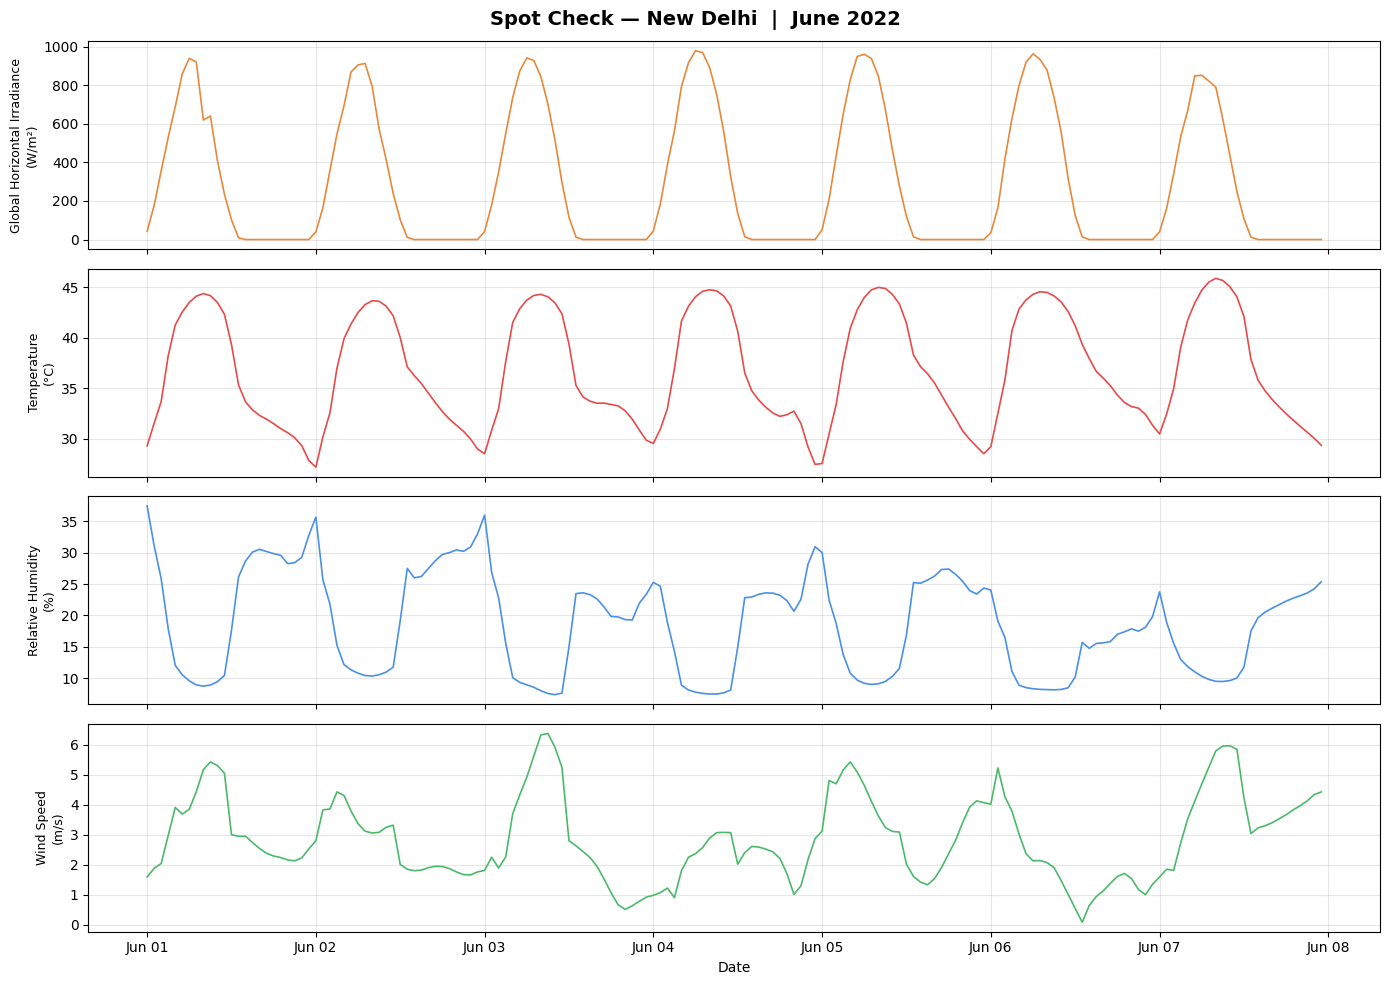

💾 Plot saved → ..\outputs\plots\spot_check_new_delhi.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick one city to spot-check
SPOT_CITY = "new_delhi"
spot_path = os.path.join(RAW_DIR, f"{SPOT_CITY}_raw.csv")

if os.path.exists(spot_path):
    spot_df = pd.read_csv(spot_path, index_col="datetime", parse_dates=True)

    # Plot one week of GHI + temperature
    sample = spot_df.loc["2022-06-01":"2022-06-07"]

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        f"Spot Check — {SPOT_CITY.replace('_',' ').title()}  |  June 2022",
        fontsize=14, fontweight="bold"
    )

    plot_cfg = [
        ("GHI",              "Global Horizontal Irradiance", "W/m²",  "#E8883A"),
        ("temperature",      "Temperature",                  "°C",    "#E84A4A"),
        ("humidity",         "Relative Humidity",            "%",     "#4A90E8"),
        ("wind_speed",       "Wind Speed",                   "m/s",   "#4ABA6A"),
    ]

    for ax, (col, label, unit, color) in zip(axes, plot_cfg):
        ax.plot(sample.index, sample[col], color=color, linewidth=1.2)
        ax.set_ylabel(f"{label}\n({unit})", fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    axes[-1].set_xlabel("Date", fontsize=10)
    plt.tight_layout()

    plot_path = os.path.join("..", "outputs", "plots", f"spot_check_{SPOT_CITY}.png")
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"💾 Plot saved → {plot_path}")
else:
    print(f"⚠️  {spot_path} not found — run Cell 7 first")

In [13]:
print("=" * 60)
print("  NOTEBOOK 01 — COMPLETE")
print("=" * 60)

raw_files = [f for f in os.listdir(RAW_DIR) if f.endswith("_raw.csv")]
total_rows = 0

for f in sorted(raw_files):
    path  = os.path.join(RAW_DIR, f)
    rows  = pd.read_csv(path, index_col=0).shape[0]
    total_rows += rows
    print(f"  📁 {f:<30} {rows:>8,} rows")

print(f"\n  Total rows across all cities : {total_rows:,}")
print(f"  Ready for → 02_preprocessing.ipynb")

  NOTEBOOK 01 — COMPLETE
  📁 cairo_raw.csv                    26,280 rows
  📁 dubai_raw.csv                    26,280 rows
  📁 istanbul_raw.csv                 26,280 rows
  📁 london_raw.csv                   26,280 rows
  📁 los_angeles_raw.csv              26,280 rows
  📁 nairobi_raw.csv                  26,280 rows
  📁 new_delhi_raw.csv                26,280 rows
  📁 riyadh_raw.csv                   26,280 rows
  📁 sydney_raw.csv                   26,280 rows
  📁 tokyo_raw.csv                    26,280 rows

  Total rows across all cities : 262,800
  Ready for → 02_preprocessing.ipynb
